In [5]:
#imports
import os
import numpy as np
from nilearn import plotting, image
import pandas as pd
import hcp_utils as hcp
import nilearn.connectome as nic
import matplotlib.pyplot as plt
import re
import scipy.stats as stats

In [6]:
file_path  = '/home/anmarkova/teams/a05/group_2/parcellations'
sub_list = os.listdir(file_path)
mmp = {}
ca = {}
sub_ids_mmp = []
sub_ids_ca = []
for i in sub_list:
    if 'mmp' in i:
        mmp_file = np.load(file_path+'/'+i)
        if mmp_file.shape == (3600, 379):
            key = int(re.search(r"sub-(\d+)", i).group(1))
            mmp[key] = mmp_file
    if 'ca' in i:
        ca_file = np.load(file_path+'/'+i)
        if ca_file.shape == (3600, 718):
            key = int(re.search(r"sub-(\d+)", i).group(1))
            ca[key] = ca_file

In [7]:
df = pd.read_csv('/home/anmarkova/teams/a05/group_2/handedness_data.csv')

In [25]:
#check that the order of subjects is the same
df['Subject'].to_list() == list(ca.keys())

True

In [28]:
handedness = df['Handedness'].to_numpy()

In [8]:
ca_data = np.array(list(ca.values()))

In [11]:
ca_data.shape

(172, 3600, 718)

In [102]:
#Correlation matrix
correlation_measure = nic.ConnectivityMeasure(kind='partial correlation')
correlation_matrix = correlation_measure.fit_transform(ca_data)

#replace 1.0 with 0.999 correlations
copy_matrix = correlation_matrix.copy()
copy_matrix[copy_matrix == 1.00] = np.nan

fisher_z_matrices = np.arctanh(copy_matrix)

In [182]:
def sig_pvals(fisher_z_matrices):
    corr_mat = {}
    pval_mat = {}
    count_pval = 0
    matrix_dim = fisher_z_matrices.shape
    for i in range(matrix_dim[1]):
        for j in range(i, matrix_dim[1]):
            if i != j:
                corr, pval = stats.pearsonr(fisher_z_matrices[:,i, j],  handedness)
                corr_mat[(i, j)] = corr
                pval_mat[(i,j)] = pval
                if abs(pval) < 0.05:
                    # print(f'pair ({i}, {j}) has a pval of {pval}')
                    count_pval += 1
    print(count_pval)
    return corr_mat, pval_mat

In [78]:
#all significant correlations
corr_sig = np.array(list(corr_mat.values()))

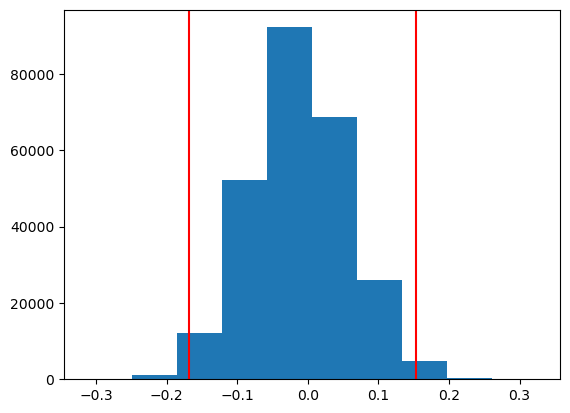

In [79]:
plt.hist(corr_sig)
bottom_5, top_5 = np.percentile(corr_sig, [1, 99])
plt.axvline(bottom_5, color='red')
plt.axvline(top_5, color = 'red')

In [80]:
sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])


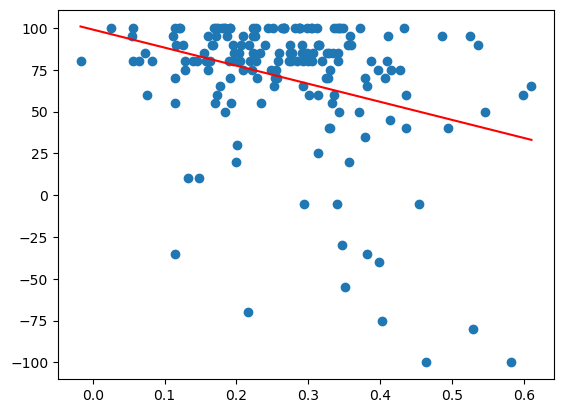

In [93]:
order = 0

coefficients = np.polyfit(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness, 1)
polynomial = np.poly1d(coefficients)
y_regression = polynomial(np.sort(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]]))

plt.plot(np.sort(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]]), y_regression, color='red')

plt.scatter(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness)

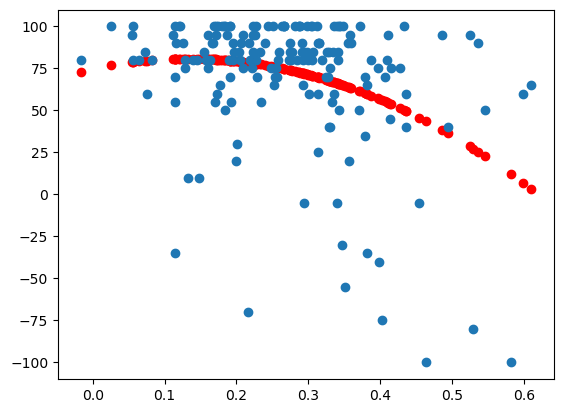

In [101]:
coefficients = np.polyfit(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness, 2)
polynomial = np.poly1d(coefficients)
y_regression = polynomial(np.sort(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]]))

plt.scatter(np.sort(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]]), y_regression, color='red')

plt.scatter(fisher_z_matrices[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness)

In [ ]:
#we can see that the correlations in our data are not strong

#what if we simulated the data

/tmp/ipykernel_423/2582700982.py:12: RuntimeWarning: overflow encountered in exp
  sinusoidal = (f1 * np.sin(s1 * x) + f2 * np.sin(s2 * np.exp(x)) + f3 * np.sin(s3 * np.pi * x))
/tmp/ipykernel_423/2582700982.py:12: RuntimeWarning: overflow encountered in multiply
  sinusoidal = (f1 * np.sin(s1 * x) + f2 * np.sin(s2 * np.exp(x)) + f3 * np.sin(s3 * np.pi * x))
/tmp/ipykernel_423/2582700982.py:12: RuntimeWarning: invalid value encountered in sin
  sinusoidal = (f1 * np.sin(s1 * x) + f2 * np.sin(s2 * np.exp(x)) + f3 * np.sin(s3 * np.pi * x))


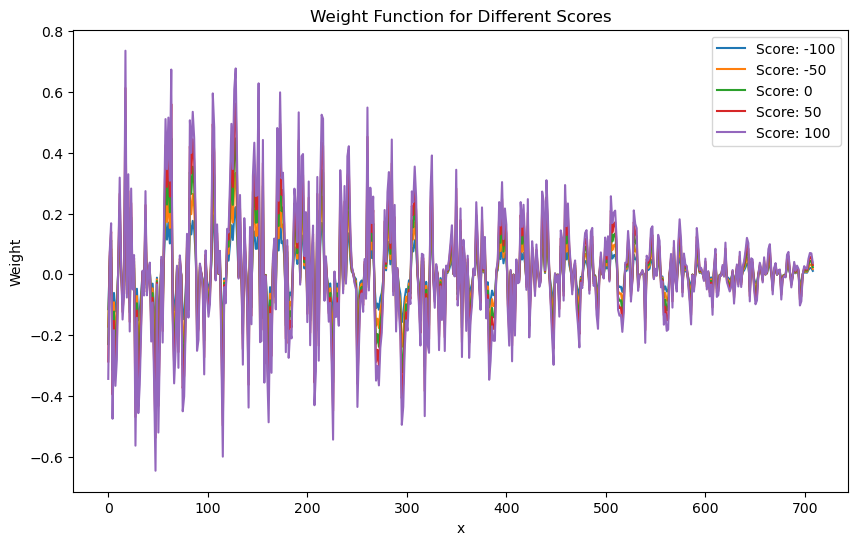

In [143]:
def weight_function(x, score, amp_0=0.1, f1=1.9, s1=3, f2=6, s2=5, f3=4.5, s3=1.3, w=350, b0=0, c=0.1, alpha=0.5):
    """
    Generates weights correlated with a score (-100 to 100)
    """
    # Compute b as a function of score
    b = b0 + c * score
    
    # Compute amp as a function of score
    amp = amp_0 * (1 + alpha * score / 100)
    
    # Sinusoidal component
    sinusoidal = (f1 * np.sin(s1 * x) + f2 * np.sin(s2 * np.exp(x)) + f3 * np.sin(s3 * np.pi * x))
    
    # Gaussian component
    gaussian = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - b) / w) ** 2)
    
    # Final weight function
    return amp * sinusoidal * gaussian

# Example usage
x_values = np.linspace(0, 718, 500)
scores = [-100, -50, 0, 50, 100]  # Example scores

plt.figure(figsize=(10, 6))
for score in scores:
    weights = weight_function(x_values, score)
    plt.plot(x_values, weights, label=f'Score: {score}')

plt.xlabel('x')
plt.ylabel('Weight')
plt.legend()
plt.title('Weight Function for Different Scores')
plt.show()


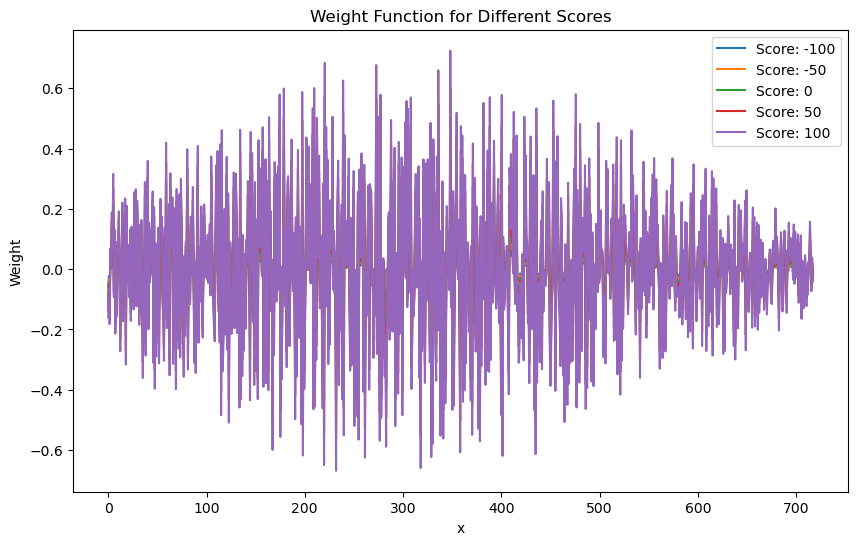

In [149]:
def weight_function(x, score, amp_0=0.1, f1=1.9, s1=3, f2=6, s2=5, f3=4.5, s3=1.3, w=250, b0=300, c=0.1, alpha=0.5, exp_damp=0.1):
    """
    Generates weights correlated with a score (-100 to 100)
    """
    # Compute b as a function of score
    b = b0 + c * score
    
    # Compute amp as a function of score
    amp = amp_0 * (1 + alpha * score / 100)
    
    # Sinusoidal component with dampened exponent to prevent overflow
    sinusoidal = (f1 * np.sin(s1 * x) + f2 * np.sin(s2 * np.exp(exp_damp * x)) + f3 * np.sin(s3 * np.pi * x))
    
    # Gaussian component
    gaussian = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - b) / w) ** 2)
    
    # Final weight function
    return amp * sinusoidal * gaussian

# Example usage
x_values = np.linspace(0, 717, 1000)
scores = [-100, -50, 0, 50, 100]  # Example scores

plt.figure(figsize=(10, 6))
for score in scores:
    weights = weight_function(x_values, score)
    plt.plot(x_values, weights, label=f'Score: {score}')

plt.xlabel('x')
plt.ylabel('Weight')
plt.legend()
plt.title('Weight Function for Different Scores')
plt.show()

In [199]:
def generate_gaussian_noise(rows, cols, mean=0, std_dev=0.2):
    """
    Generates a Gaussian noise matrix of given shape.
    """
    return np.random.normal(mean, std_dev, (rows, cols))

In [261]:
def generate_random_sequence(size, low=0, high=718):
    np.random.seed(10)
    return np.random.randint(low, high, size)

In [283]:
fake_data = []
for i in range(172):
    fake_mat = generate_gaussian_noise(718, 718)
    fake_data.append(fake_mat)

In [169]:
#correlation_matrix[np.isnan(correlation_matrix)] = 1.0

In [299]:
def correlate(fake_data, rand_sample):
    forced_mat = []
    for i, mat in enumerate(fake_data):
        score = handedness[i]
        weight_score = np.array(weight_function(np.linspace(0, 1, 718), score))
        weight_score[rand_sample] = 1
        
        W = np.diag(weight_score)
        mat = np.matmul(W, fake_data[i])
        # mat[mat >= 1.0] = 0.99 
        # z_trans = np.arctanh(mat)
        forced_mat.append(mat)
        if i%10 == 0:
            print(i)
    return np.array(forced_mat)

In [302]:
splits = np.linspace(1, 0.1, 5)
means = []
for i in splits:
    rand_sample = generate_random_sequence(int(718*i))
    forced_mat = correlate(fake_data, rand_sample)
    means.append(forced_mat.mean())

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170


In [303]:
means

[np.float64(-2.6635750636414258e-05),
 np.float64(-2.2626876027641358e-05),
 np.float64(-2.996228793641748e-05),
 np.float64(-2.1654191596834125e-05),
 np.float64(-1.3670066604962626e-06)]

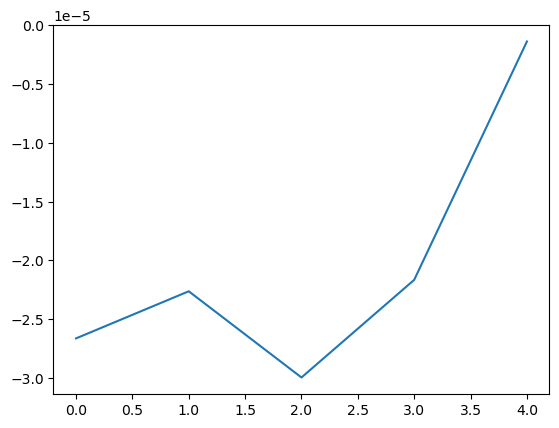

In [304]:
plt.plot(means)

In [290]:
means

[array([[ 0.04153472,  0.06418217, -0.11584563, ..., -0.52276771,
          0.2536103 ,  0.14088219],
        [-0.02447209,  0.01045635,  0.01736942, ..., -0.01251681,
         -0.01450354, -0.04342431],
        [ 0.32925631,  0.12616817, -0.19426079, ..., -0.29866072,
         -0.11639915,  0.38753587],
        ...,
        [ 0.08674207,  0.14434048, -0.12647133, ...,  0.0158376 ,
         -0.04556488,  0.18152035],
        [ 0.03811524,  0.03685516, -0.01720311, ...,  0.03936847,
          0.00524575, -0.00060301],
        [-0.25411122, -0.18199292,  0.07655133, ...,  0.05211173,
          0.47020806, -0.33658924]], shape=(718, 718)),
 array([[-3.16905664e-02,  2.66755786e-01,  5.90228446e-03, ...,
         -3.05515106e-02,  3.59014680e-02,  1.55488397e-01],
        [ 3.05462115e-02,  3.70735879e-02, -2.38267516e-02, ...,
          5.74609820e-03, -6.70603710e-03,  5.24068499e-03],
        [-5.08192786e-02,  2.13893209e-01, -2.21285055e-01, ...,
          5.44878786e-02, -1.69570347e

In [177]:
z_forced_mat = np.arctanh(forced_mat)

In [184]:
corr_mat, pval_mat = sig_pvals(z_forced_mat)

257403


In [185]:
#all significant correlations
corr_sig = np.array(list(corr_mat.values()))

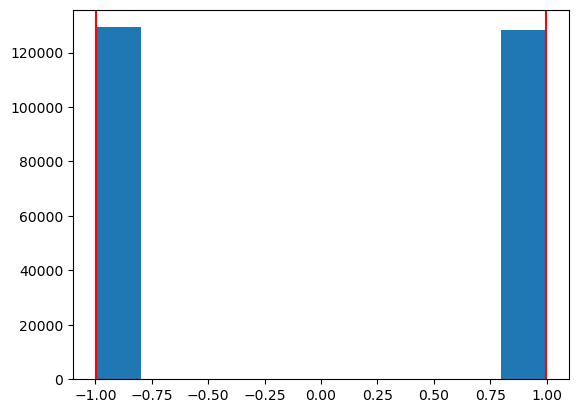

In [186]:
plt.hist(corr_sig)
bottom_5, top_5 = np.percentile(corr_sig, [1, 99])
plt.axvline(bottom_5, color='red')
plt.axvline(top_5, color = 'red')

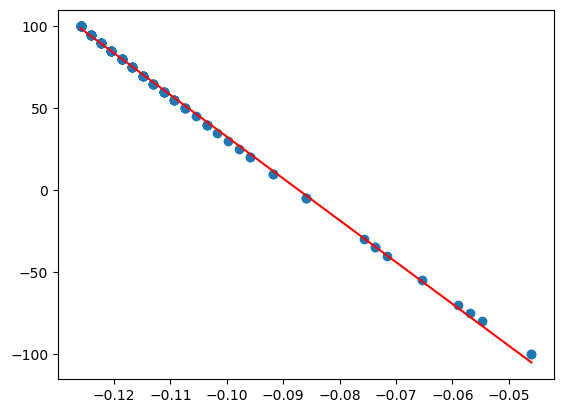

In [188]:
order = 0
sorted_keys = sorted(corr_mat, key=lambda x: corr_mat[x])

coefficients = np.polyfit(z_forced_mat[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness, 1)
polynomial = np.poly1d(coefficients)
y_regression = polynomial(np.sort(z_forced_mat[:, sorted_keys[order][0], sorted_keys[order][1]]))

plt.plot(np.sort(z_forced_mat[:, sorted_keys[order][0], sorted_keys[order][1]]), y_regression, color='red')

plt.scatter(z_forced_mat[:, sorted_keys[order][0], sorted_keys[order][1]],  handedness)

In [192]:
np.array(forced_mat).mean()

np.float64(-0.00012015917491688451)

In [280]:
correlation_matrix[4].mean()

np.float32(0.0024537859)